In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata
import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import plotting,utils, processing
allmeshes = utils.load_mesh()

import squidpy as sq
import scanpy as sc

import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")


/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import numpy as np


In [3]:
adata_foo = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files/snRNAseq_LCNE_BN_new.h5ad")
adata_sc = anndata.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 


adata_mer = adata_mer[adata_mer.obs['leiden']!='5',:]
adata_mer.shape
adata_mer.X = adata_mer.X * 1e4

In [4]:
genename = 'Tacr3'

coords  = adata_mer.obsm['spatial'].copy()
y = np.array(adata_mer[:,genename].X)
reg = LinearRegression().fit(coords, y)
y_pred = reg.predict(coords)
residuals = y - y_pred   # shape (N,)

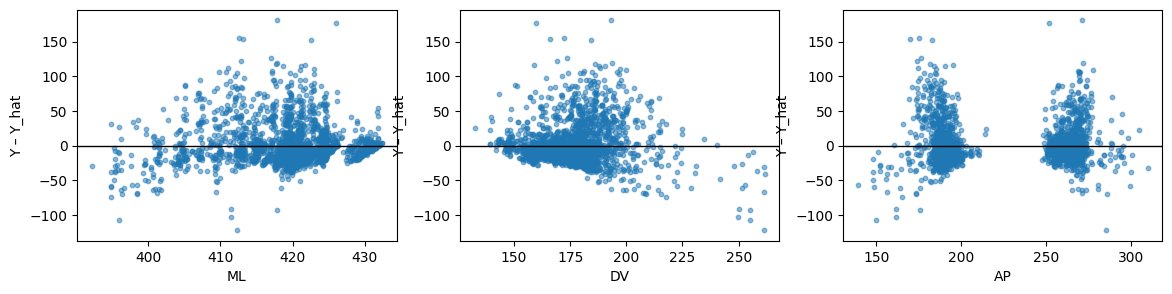

In [5]:
axis_names = ['ML','DV','AP']
plt.figure(figsize = (14,3))
import matplotlib.pyplot as plt
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.scatter(coords[:,i], residuals, s=10, alpha=0.5)
    plt.axhline(0, color="k", lw=1)
    plt.ylabel("Y – Y_hat")
    plt.xlabel(f'{axis_names[i]}')